# Sampling from random quantum circuits

In this notebook, we will sample from quantum random circuits and compare the distribution we obtain to the theoretical distribution

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.random import random_circuit
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import Statevector

We define the parameters we are going to use for the random circuits. A statevector sampler will sample from the circuits, and a statevector will provide the exact probability of each sampled string.

In [2]:
n_circs = 10000
n_qubits = 4
n_layers = 30
freq = []
sampler = StatevectorSampler()

Now, we generate random circuits and we sample one string from each. Then, we obtain the exact probability of that string.

In [4]:
circuits = [random_circuit(n_qubits, n_layers, measure=False) for _ in range(n_circs)]
meas = QuantumCircuit(n_qubits, n_qubits)
meas.measure(range(n_qubits), range(n_qubits))

# Sample one string from each random circuit in a single Primitives V2 job.
measured_circuits = [circ.compose(meas) for circ in circuits]
sampled_results = sampler.run(measured_circuits, shots=1).result()

for circ, result in zip(circuits, sampled_results):
    string = result.data.c.get_bitstrings()[0]
    # Compute the exact probability of the sampled string.
    state = Statevector.from_instruction(circ)
    freq.append(state.probabilities_dict()[string])

Now, we plot the histogram of our samples and compare it to the theoretical distribution

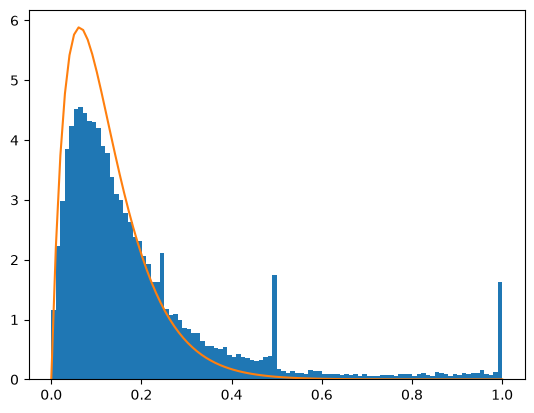

In [5]:
import numpy as np
xs = np.linspace(0.0, 1.0, 100)
dim = 2**n_qubits
ys = xs*(dim**2)*np.exp(-dim*xs)
plt.hist(freq, bins = 100, density = True)
plt.plot(xs, ys, label='Theoretical')
plt.show()